---

<div align="center">

# ***Idea de proyecto***

</div>

---

<div align="center">

## **Librerias**
</div>

In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf

<div align="center">

## **Validacion de tensorflow**
</div>

In [16]:
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.16.1
Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<div align="center">

## **Extraccion de los datos de Yahoo Finance**
</div>

In [26]:
df = yf.Ticker("^GSPC").history(period="max")
df.reset_index(inplace=True)
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1,1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
2,1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
3,1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
4,1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...,...
24437,2025-04-15 00:00:00-04:00,5411.990234,5450.410156,5386.439941,5396.629883,4317110000,0.0,0.0
24438,2025-04-16 00:00:00-04:00,5335.750000,5367.240234,5220.790039,5275.700195,4607750000,0.0,0.0
24439,2025-04-17 00:00:00-04:00,5305.450195,5328.310059,5255.580078,5282.700195,4714880000,0.0,0.0
24440,2025-04-21 00:00:00-04:00,5232.939941,5232.939941,5101.629883,5158.200195,4226340000,0.0,0.0


<div align="center">

## **Codigo que da Claude**
</div>

Preparemos los datos para el entrenamiento de la red neuronal. Calcularemos los retornos logarítmicos diarios, que son más adecuados para modelado financiero:

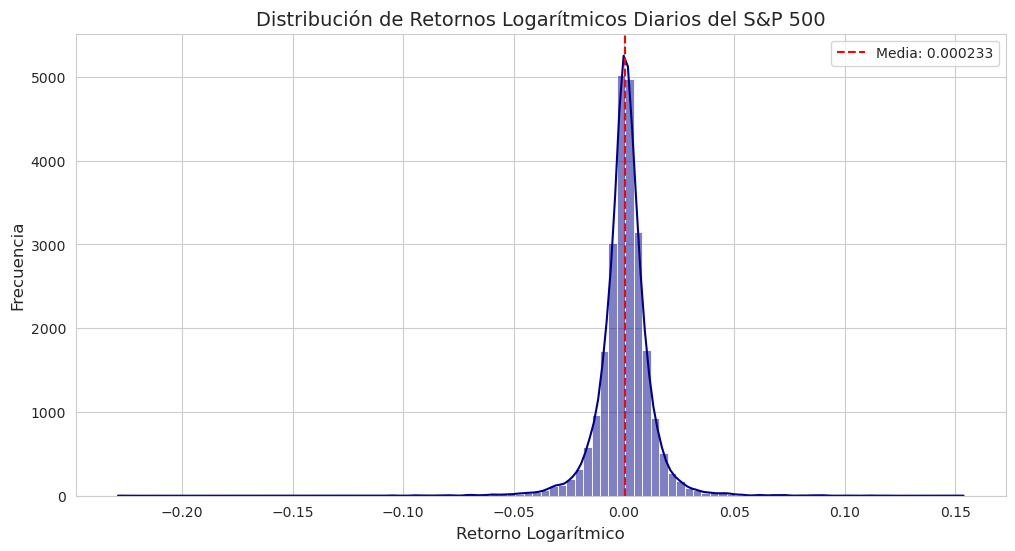

Estadística Jarque-Bera: 357192.9876, p-valor: 0.00000000
Curtosis: 18.7051
Asimetría: -0.4658


In [28]:
# Calcular retornos logarítmicos diarios
df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()  # Eliminar la primera fila con NaN

# Visualizar la distribución de retornos
plt.figure(figsize=(12, 6))
sns.histplot(df['LogReturn'], kde=True, bins=100, color='darkblue')
plt.title('Distribución de Retornos Logarítmicos Diarios del S&P 500', fontsize=14)
plt.xlabel('Retorno Logarítmico', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.axvline(df['LogReturn'].mean(), color='red', linestyle='--', label=f'Media: {df["LogReturn"].mean():.6f}')
plt.legend()
plt.show()

# Prueba de normalidad (Jarque-Bera)
jb_stat, jb_pvalue = stats.jarque_bera(df['LogReturn'])
print(f"Estadística Jarque-Bera: {jb_stat:.4f}, p-valor: {jb_pvalue:.8f}")
print(f"Curtosis: {stats.kurtosis(df['LogReturn']):.4f}")
print(f"Asimetría: {stats.skew(df['LogReturn']):.4f}")

Ahora, definamos la estructura de nuestra red neuronal generativa. Implementaremos un modelo basado en LSTM (Long Short-Term Memory) para capturar patrones temporales en los retornos:

2025-04-23 02:15:59.007036: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23 02:15:59.007148: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23 02:15:59.007198: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23 02:15:59.305118: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-23 02:15:59.305233: I external/local_xla/xla/stream_executor

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,153 (332.63 KB)

 Trainable params: 85,153 (332.63 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100


2025-04-23 02:16:01.927248: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


611/611 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - loss: 1.0144 - val_loss: 1.0753
Epoch 2/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.9349 - val_loss: 1.0730
Epoch 3/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.9605 - val_loss: 1.0724
Epoch 4/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.9933 - val_loss: 1.0739
Epoch 5/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.9784 - val_loss: 1.0680
Epoch 6/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.9432 - val_loss: 1.0688
Epoch 7/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.9478 - val_loss: 1.0674
Epoch 8/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.9489 - val_loss: 1.0649
Epoch 9/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.9423 - val_loss: 1.0710
Epoch 10/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.9310 - val_loss: 1.0636
Epoch 11/100
611/611 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.9366 - val_loss: 1.0816
Epoch 12/100
611/611 ━━━━━━━━━━

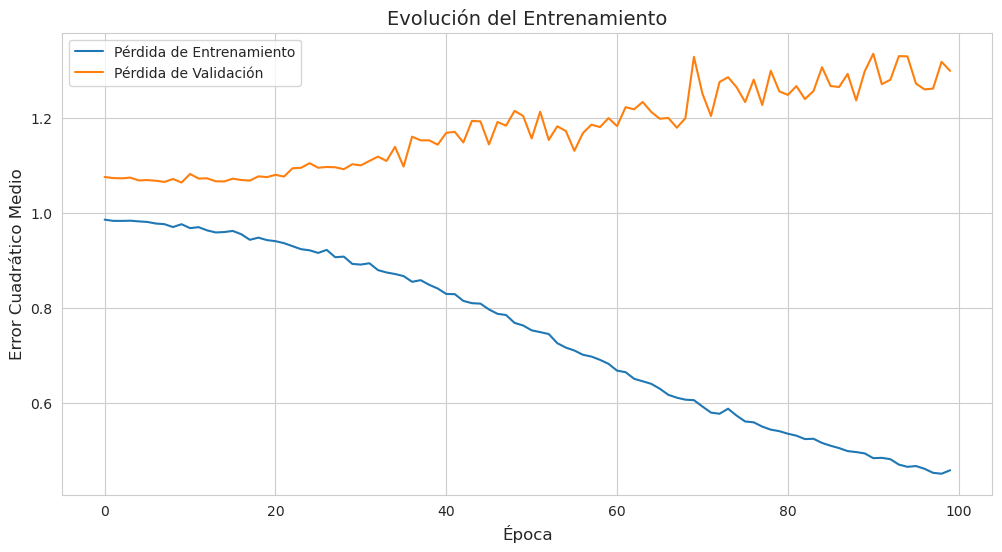

In [29]:
# Preparar secuencias temporales para entrenar el modelo
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Longitud de secuencia (ventana temporal)
seq_length = 30  # 30 días para capturar patrones de un mes aproximadamente

# Obtener retornos y normalizar
returns = df['LogReturn'].values
mean_return = returns.mean()
std_return = returns.std()
normalized_returns = (returns - mean_return) / std_return

# Crear secuencias
X, y = create_sequences(normalized_returns, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Dividir en conjuntos de entrenamiento y validación
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Arquitectura del modelo generativo
def create_lstm_generator(seq_length, latent_dim=32):
    inputs = Input(shape=(seq_length, 1))
    
    # Capas LSTM con dropout para prevenir sobreajuste
    x = LSTM(100, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(64)(x)
    x = Dropout(0.2)(x)
    
    # Capas densas para mapear a espacio latente y luego a predicción
    x = Dense(latent_dim, activation='relu')(x)
    outputs = Dense(1, activation='linear')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    return model

# Crear y entrenar el modelo
generator = create_lstm_generator(seq_length)
print(generator.summary())

# Entrenar el modelo
history = generator.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Visualizar el proceso de entrenamiento
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Evolución del Entrenamiento', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error Cuadrático Medio', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

Ahora, implementemos el método de Monte Carlo para simular trayectorias y calcular el VaR:

In [ ]:
# Preparar última secuencia conocida
last_known_returns = normalized_returns[-seq_length:].reshape(1, seq_length, 1)

# Obtener el último precio conocido antes de generar las simulaciones
last_price = df['Close'].iloc[-1]

# Generar simulaciones
horizon = 30  # Horizonte de 30 días (aprox. 1 mes)
num_sims = 10000  # Número de simulaciones

def generate_monte_carlo_paths(model, last_sequence, last_price, num_days, num_simulations):
    """
    Genera simulaciones de Monte Carlo utilizando el modelo entrenado.
    
    Parámetros:
    model: Modelo LSTM entrenado
    last_sequence: Última secuencia conocida de retornos normalizados
    last_price: Último precio conocido
    num_days: Número de días a simular hacia adelante
    num_simulations: Número de trayectorias a simular
    
    Retorna:
    Array de simulaciones de retornos y precios
    """
    # Asegurarse que last_sequence tiene la forma correcta
    if len(last_sequence.shape) < 3:
        last_sequence = last_sequence.reshape((1, last_sequence.shape[0], 1))
    
    # Matrices para almacenar simulaciones
    simulated_returns = np.zeros((num_simulations, num_days))
    simulated_prices = np.zeros((num_simulations, num_days + 1))
    simulated_prices[:, 0] = last_price
    
    for sim in range(num_simulations):
        # Copiar la secuencia inicial para esta simulación
        curr_sequence = last_sequence.copy()
        
        for day in range(num_days):
            # Predecir el próximo retorno normalizado
            pred_normalized = model.predict(curr_sequence, verbose=0)[0, 0]
            
            # Agregar ruido aleatorio para generar variabilidad
            noise = np.random.normal(0, 0.5)  # Ajustar std para control de volatilidad
            pred_normalized += noise
            
            # Desnormalizar para obtener el retorno logarítmico real
            pred_return = pred_normalized * std_return + mean_return
            simulated_returns[sim, day] = pred_return
            
            # Actualizar precio
            simulated_prices[sim, day + 1] = simulated_prices[sim, day] * np.exp(pred_return)
            
            # Actualizar secuencia para el próximo paso
            curr_sequence = np.roll(curr_sequence, -1, axis=1)
            curr_sequence[0, -1, 0] = pred_normalized
    
    return simulated_returns, simulated_prices

# Llamar a la función con todos los parámetros necesarios
simulated_returns, simulated_prices = generate_monte_carlo_paths(
    generator, last_known_returns, last_price, horizon, num_sims
)

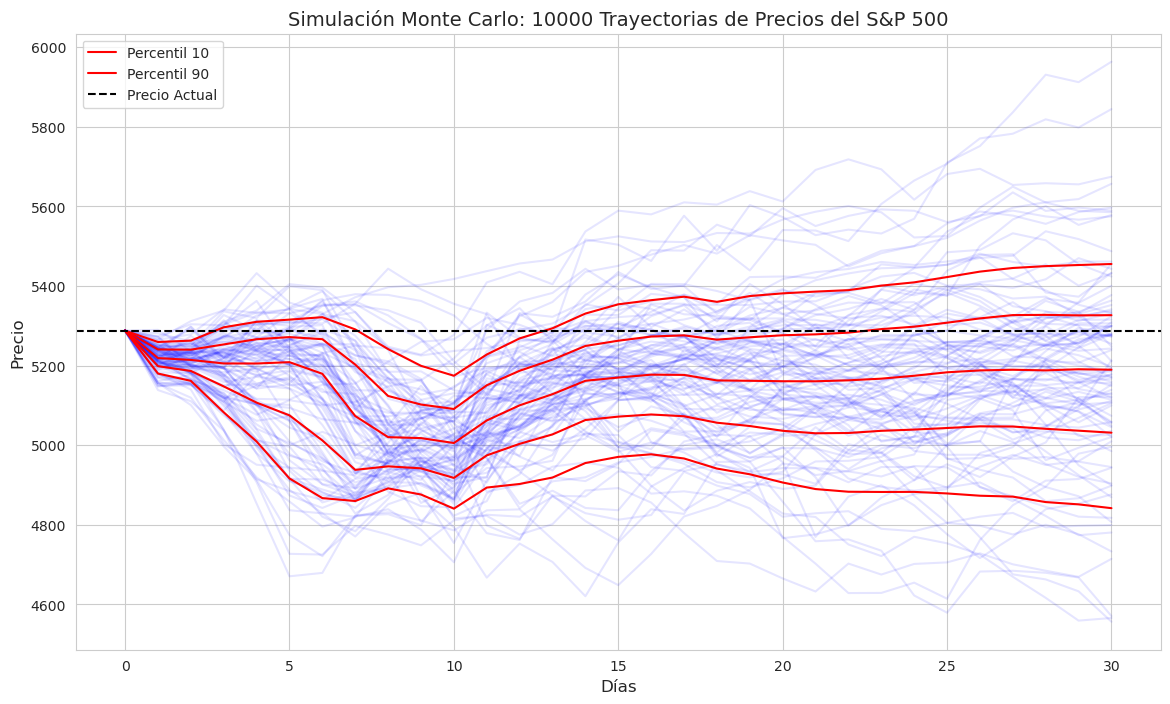

In [36]:
last_price = df['Close'].iloc[-1]
# Visualizar algunas trayectorias simuladas
plt.figure(figsize=(14, 8))
for i in range(100):  # Mostrar solo 100 trayectorias para claridad
    plt.plot(range(horizon + 1), simulated_prices[i], 'b-', alpha=0.1)
    
# Agregar percentiles para visualizar la dispersión
percentiles = [10, 25, 50, 75, 90]
perc_values = np.percentile(simulated_prices, percentiles, axis=0)
for i, p in enumerate(percentiles):
    plt.plot(range(horizon + 1), perc_values[i], 'r-', linewidth=1.5, 
             label=f'Percentil {p}' if i == 0 or i == len(percentiles)-1 else None)

plt.title(f'Simulación Monte Carlo: {num_sims} Trayectorias de Precios del S&P 500', fontsize=14)
plt.xlabel('Días', fontsize=12)
plt.ylabel('Precio', fontsize=12)
plt.axhline(y=last_price, color='k', linestyle='--', label='Precio Actual')
plt.legend()
plt.grid(True)
plt.show()

Finalmente, calculemos el VaR (Valor en Riesgo) a diferentes niveles de confianza:

VaR al 90.0% de confianza: $84,327.79
VaR al 95.0% de confianza: $109,327.05
VaR al 99.0% de confianza: $162,054.74


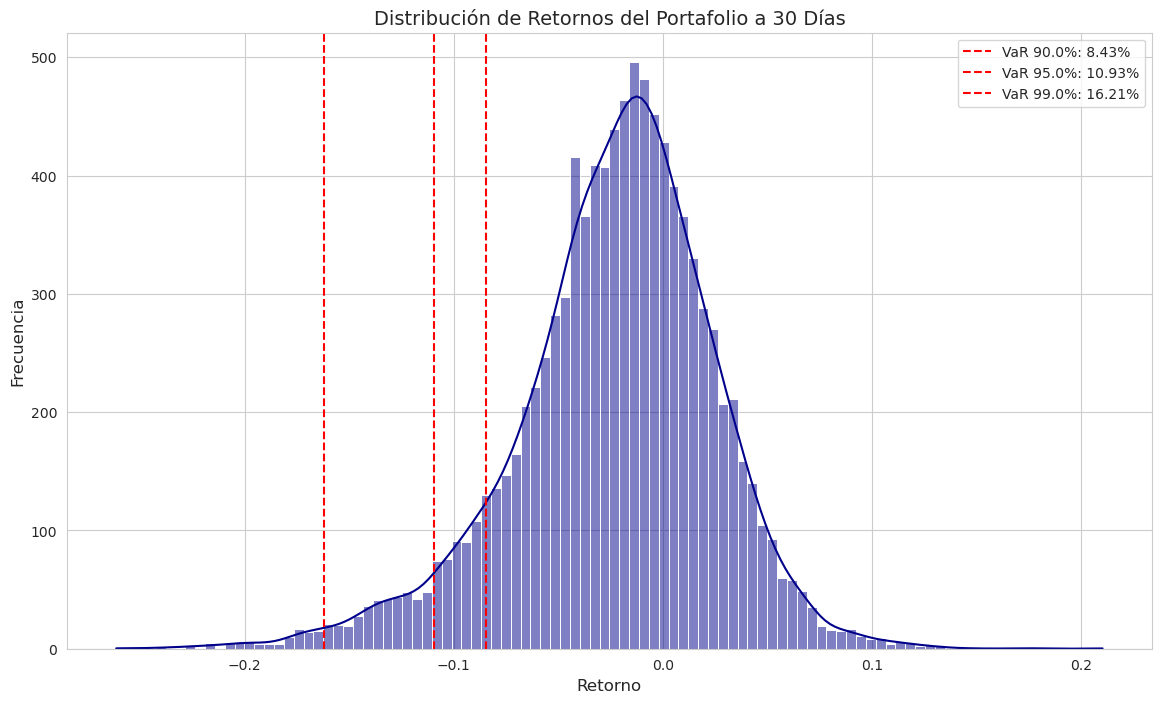

Expected Shortfall al 90.0%: $119,050.74
Expected Shortfall al 95.0%: $142,449.90
Expected Shortfall al 99.0%: $186,846.81
Parámetros GEV - ξ: -0.3790, μ: 0.1018, σ: 0.0171
VaR 99% empírico: 16.21%
VaR 99% según GEV: -8.19%
VaR 99% histórico (1 día): 3.50%


In [35]:
# Calcular retornos del portafolio para el horizonte especificado
portfolio_value = 1000000  # Valor inicial del portafolio (1 millón)
final_values = simulated_prices[:, -1] * portfolio_value / last_price
returns = (final_values - portfolio_value) / portfolio_value

# Calcular VaR a diferentes niveles de confianza
confidence_levels = [0.90, 0.95, 0.99]
var_values = {}

for cl in confidence_levels:
    var_values[cl] = -np.percentile(returns, (1-cl)*100)
    print(f"VaR al {cl:.1%} de confianza: ${portfolio_value * var_values[cl]:,.2f}")

# Visualizar distribución de retornos y VaR
plt.figure(figsize=(14, 8))
sns.histplot(returns, bins=100, kde=True, color='darkblue')
plt.title('Distribución de Retornos del Portafolio a 30 Días', fontsize=14)
plt.xlabel('Retorno', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

for cl in confidence_levels:
    plt.axvline(-var_values[cl], color='red', linestyle='--', 
                label=f'VaR {cl:.1%}: {var_values[cl]:.2%}')

plt.legend()
plt.grid(True)
plt.show()

# Calcular Expected Shortfall (ES) / Conditional VaR
es_values = {}
for cl in confidence_levels:
    threshold = -var_values[cl]
    es_values[cl] = -np.mean(returns[returns <= threshold])
    print(f"Expected Shortfall al {cl:.1%}: ${portfolio_value * es_values[cl]:,.2f}")

# Análisis de cola mediante teoría de valores extremos
from scipy.stats import genextreme

# Ajustar distribución GEV a los retornos negativos para modelar eventos extremos
losses = -returns
losses_sorted = np.sort(losses)
tail_threshold = np.percentile(losses, 90)  # Considerar el 10% más extremo
tail_losses = losses[losses > tail_threshold]

# Ajustar modelo GEV
shape, loc, scale = genextreme.fit(tail_losses)
print(f"Parámetros GEV - ξ: {shape:.4f}, μ: {loc:.4f}, σ: {scale:.4f}")

# Comparar VaR empírico vs VaR según GEV
empirical_var = var_values[0.99]
gev_var_99 = -genextreme.ppf(0.01, shape, loc=loc, scale=scale)
print(f"VaR 99% empírico: {empirical_var:.2%}")
print(f"VaR 99% según GEV: {gev_var_99:.2%}")

# Backtesting: Comparar con retornos históricos reales
historical_returns = df['LogReturn'].values
historical_var_99 = -np.percentile(historical_returns, 1)
print(f"VaR 99% histórico (1 día): {historical_var_99:.2%}")